<a href="https://colab.research.google.com/github/Qarym/Covid-19-Data-Analysis/blob/main/LinearRegressionModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing Libraries

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Uploading the Dataset

In [8]:
from google.colab import files
uploaded = files.upload()

Saving auto-mpg.csv to auto-mpg.csv


### Data Description

In [9]:
df=pd.read_csv('auto-mpg.csv')
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70
...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82
394,44.0,4,97.0,52.0,2130,24.6,82
395,32.0,4,135.0,84.0,2295,11.6,82
396,28.0,4,120.0,79.0,2625,18.6,82


In [10]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


In [11]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
count,398.000000,398.000000,398.000000,396.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.189394,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.402030,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,92.000000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    396 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model-year    398 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 21.9 KB


### Data Preprocessing

In [13]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,2
weight,0
acceleration,0
model-year,0


## Horsepower lacks values in two columns.

In [14]:
df[df.isnull().any(axis = 1)]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
32,25.0,4,98.0,NaN,2046,19.0,71
126,21.0,6,200.0,NaN,2875,17.0,74


## I have dropped the null values in the horsepower column

In [15]:
df.dropna(inplace = True)

In [16]:
df.isnull().sum().any()

np.False_

In [17]:
df.shape

(396, 7)

## Exploratory Data Analysis (Univariate Analysis)

In [18]:
df.cylinders.unique()

array([8, 4, 6, 3, 5])

In [19]:
df.cylinders.value_counts()

,count
cylinders,
4,203
8,103
6,83
3,4
5,3


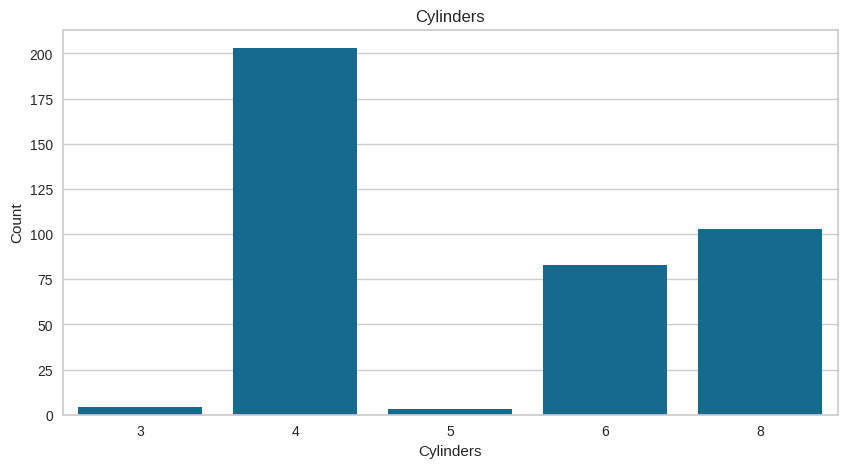

In [20]:
plt.figure(figsize = (10, 5))
sns.countplot(x = 'cylinders', data = df,)
plt.title("Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("Count")
plt.show()

In [21]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


## Change the year last two digits to four digits (e.g 70 - 1970)

In [22]:
df["model-year"] = (1900 + df["model-year"])

In [23]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
0,18.0,8,307.0,130.0,3504,12.0,1970
1,15.0,8,350.0,165.0,3693,11.5,1970
2,18.0,8,318.0,150.0,3436,11.0,1970
3,16.0,8,304.0,150.0,3433,12.0,1970
4,17.0,8,302.0,140.0,3449,10.5,1970


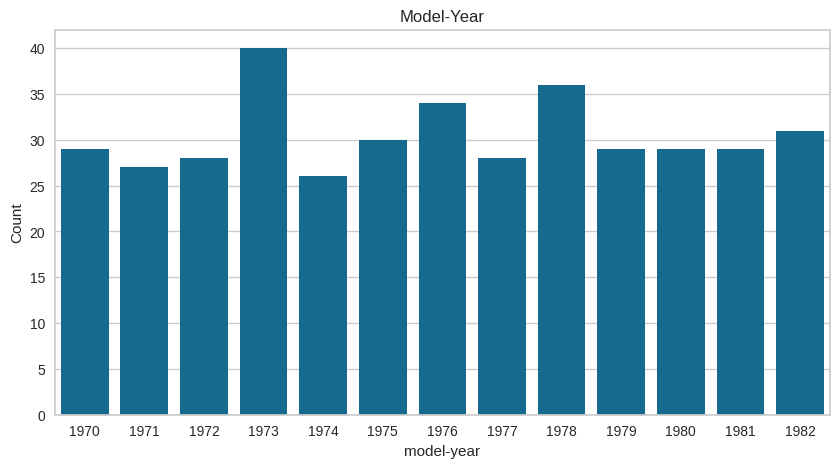

In [24]:
plt.figure(figsize = (10, 5))
sns.countplot(x = 'model-year', data = df,)
plt.title("Model-Year")
plt.xlabel("model-year")
plt.ylabel("Count")
plt.show()

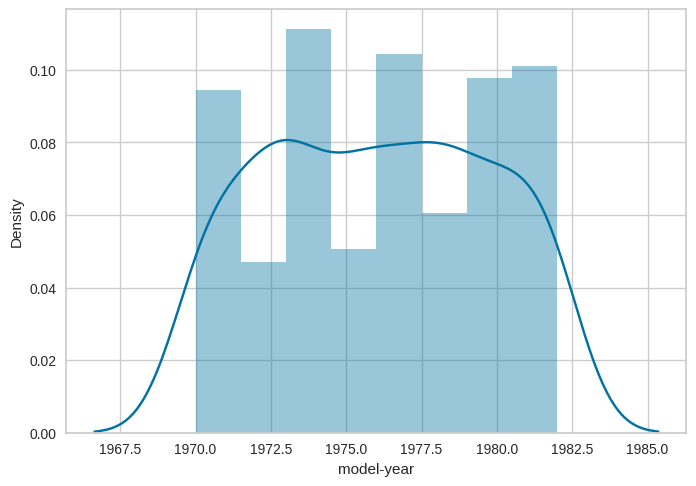

In [25]:
sns.distplot(df["model-year"])
plt.show()

## Bivariate Analysis

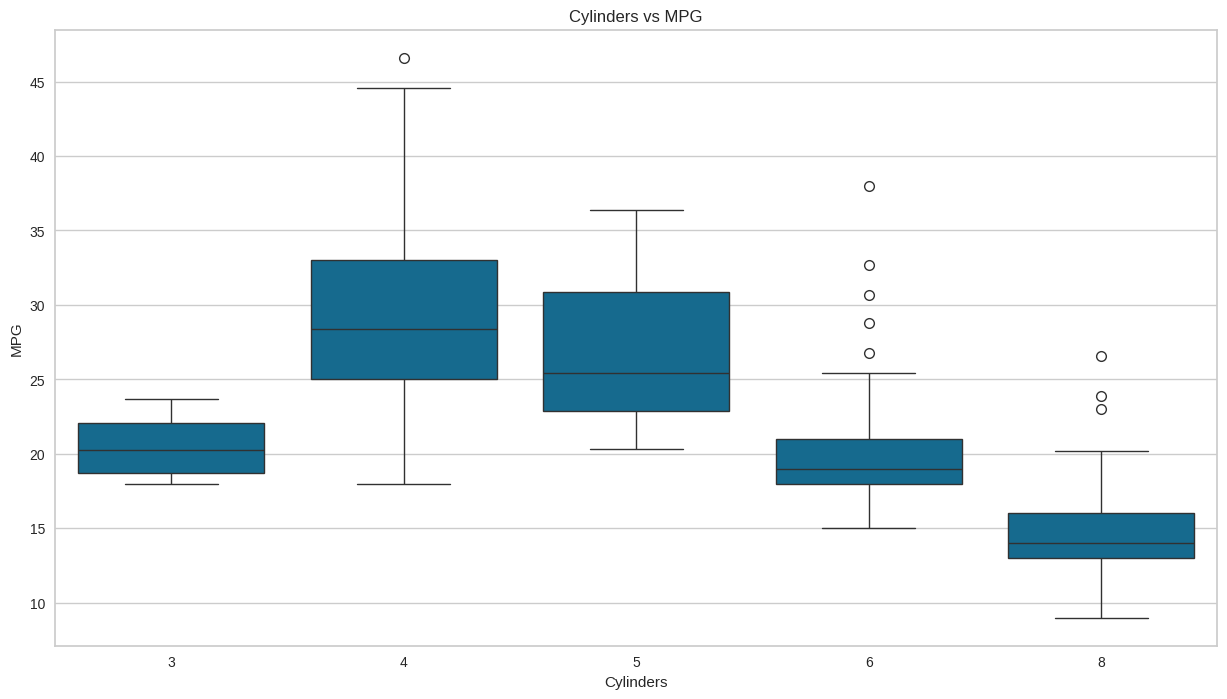

In [26]:
plt.figure(figsize = (15, 8))
sns.boxplot(x = "cylinders", y = "mpg", data = df)
plt.title("Cylinders vs MPG")
plt.xlabel("Cylinders")
plt.ylabel("MPG")
plt.show()

MPG decreases as number of cylinders incresases

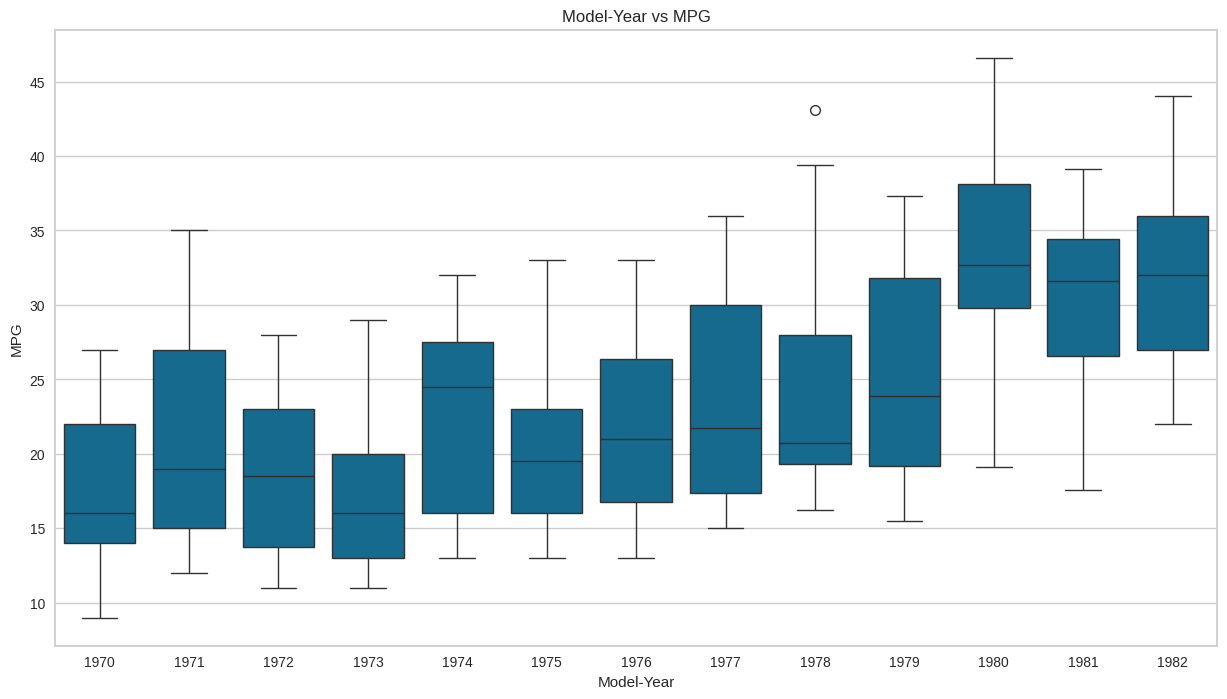

In [27]:
plt.figure(figsize = (15, 8))
sns.boxplot(x = "model-year", y = "mpg", data = df)
plt.title("Model-Year vs MPG")
plt.xlabel("Model-Year")
plt.ylabel("MPG")
plt.show()

As the year goes by the newer models of MPG Increases

## Multivariate Analysis

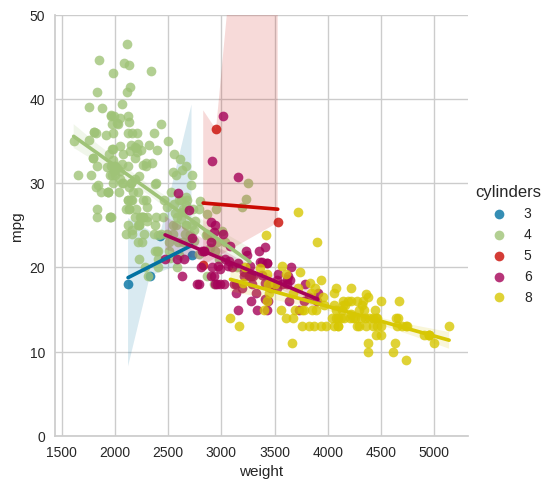

In [28]:
graph = sns.lmplot(y = "mpg", x = "weight", hue = "cylinders", data = df)
graph.set(ylim = (0, 50))
plt.show()

As the weight increases the mpg decreses

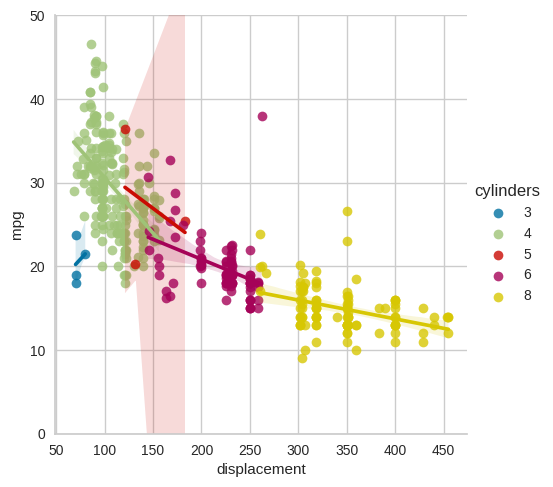

In [29]:
graph = sns.lmplot(y = "mpg", x = "displacement", hue = "cylinders", data = df)
graph.set(ylim = (0, 50))
plt.show()

As the Displacement increases the MPG decreases

## Heatmap of Correlation

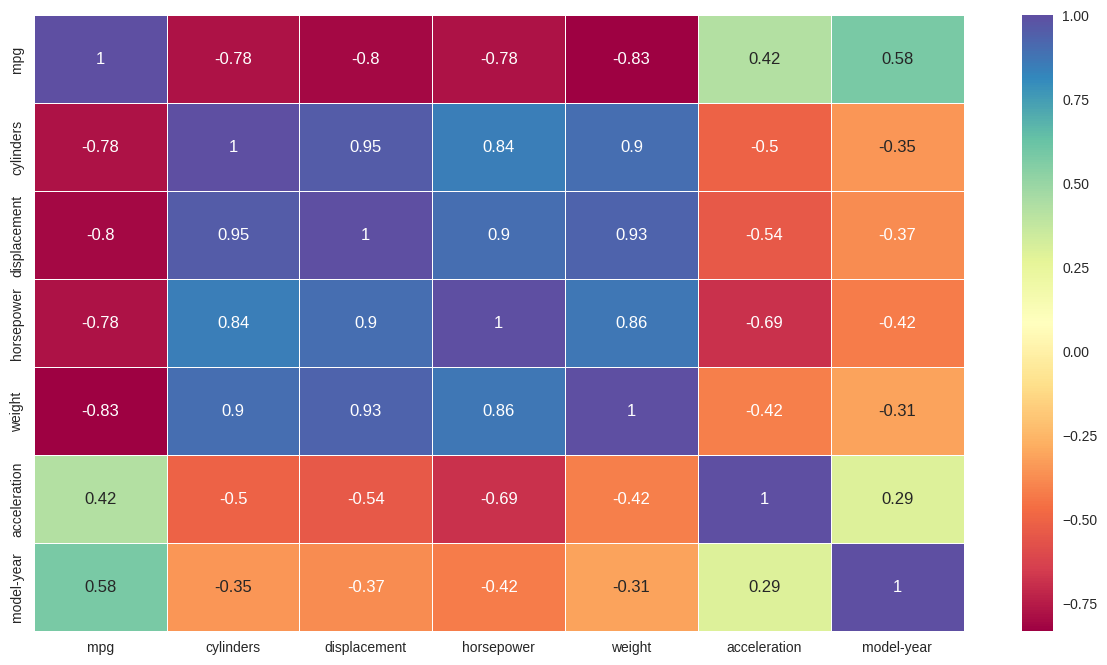

In [30]:
plt.figure(figsize = (15, 8))
sns.heatmap(df.corr(), annot = True, linewidths= 0.5, cmap= "Spectral")
plt.show()

In [31]:
df.drop(["acceleration", "displacement"], axis = 1, inplace = True)

In [32]:
df.head()

,mpg,cylinders,horsepower,weight,model-year
0,18.0,8,130.0,3504,1970
1,15.0,8,165.0,3693,1970
2,18.0,8,150.0,3436,1970
3,16.0,8,150.0,3433,1970
4,17.0,8,140.0,3449,1970


In [33]:
from datetime import datetime

In [34]:
today = datetime.today()
today

datetime.datetime(2026, 7, 30, 20, 57, 49, 932997)

In [35]:
this_year = today.year
this_year

2026

In [36]:
df["age"] = this_year - df["model-year"]

In [37]:
df.drop("model-year", axis = 1, inplace = True, errors = 'ignore')


In [38]:
df.head()

,mpg,cylinders,horsepower,weight,age
0,18.0,8,130.0,3504,56
1,15.0,8,165.0,3693,56
2,18.0,8,150.0,3436,56
3,16.0,8,150.0,3433,56
4,17.0,8,140.0,3449,56


## Modelling

In [39]:
X = df.drop("mpg", axis = 1)
y = df["mpg"]

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [41]:
X_train

,cylinders,horsepower,weight,age
339,4,84.0,2635,45
177,4,95.0,2694,51
64,8,150.0,4135,54
249,8,110.0,3365,48
229,8,180.0,4220,49
...,...,...,...,...
72,8,150.0,3892,54
107,6,100.0,2789,53
272,4,85.0,2855,48
350,4,63.0,2215,45


In [42]:
y_train

,mpg
339,26.6
177,23.0
64,15.0
249,19.9
229,16.0
...,...
72,15.0
107,18.0
272,23.8
350,34.7


In [43]:
from sklearn.linear_model import LinearRegression

In [44]:
lm_model = LinearRegression()

In [45]:
lm_model.fit(X_train, y_train)

LinearRegression()

In [46]:
lm_model.intercept_

np.float64(80.90076042962926)

In [47]:
coef_param = pd.DataFrame(lm_model.coef_, X.columns, columns = ["Coefficient"])
coef_param

,Coefficient
cylinders,-0.051284
horsepower,-0.004808
weight,-0.006586
age,-0.740619


In [48]:
y_pred = lm_model.predict(X_test)

In [49]:
my_dict = {"actual" : y_test, "predicted" : y_pred}
compare = pd.DataFrame(my_dict)
compare.sample(10)

,actual,predicted
77,22.0,23.800064
47,19.0,17.763904
174,18.0,22.703348
257,19.4,23.470486
393,27.0,29.320764
83,28.0,26.066078
111,18.0,27.073334
307,26.8,27.449632
323,27.9,27.682323
379,36.0,33.777190


In [50]:
from sklearn.metrics import mean_squared_error, r2_score

In [51]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

def evaluation_matrics(actual, pred):
    MSE = mean_squared_error(actual, pred)
    RMSE = np.sqrt(MSE)
    R2 = r2_score(actual, pred)
    MAE = mean_absolute_error(actual, pred)
    return print("r2_score:", R2, "\n", "mae:", MAE, "\n", "mse:", MSE, "\n", "rmse:", RMSE)


In [52]:
evaluation_matrics(y_test, y_pred)


r2_score: 0.789296393186258 
 mae: 2.5364759379867676 
 mse: 10.931877288825508 
 rmse: 3.3063389555255083


### Model Evaluation Visualizations

In [53]:
!pip install yellowbrick

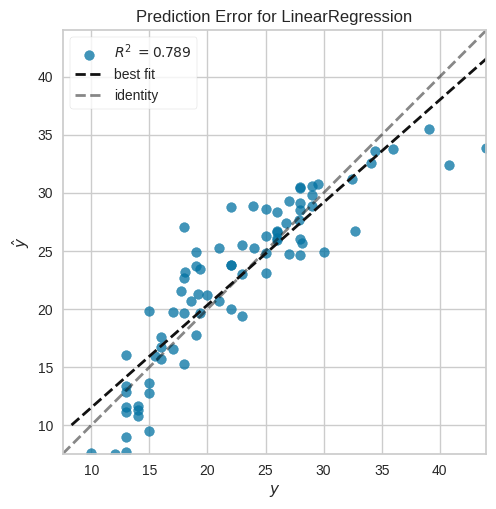

<Axes: title={'center': 'Prediction Error for LinearRegression'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [54]:
from yellowbrick.regressor import PredictionError
visualizer = PredictionError(lm_model)
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

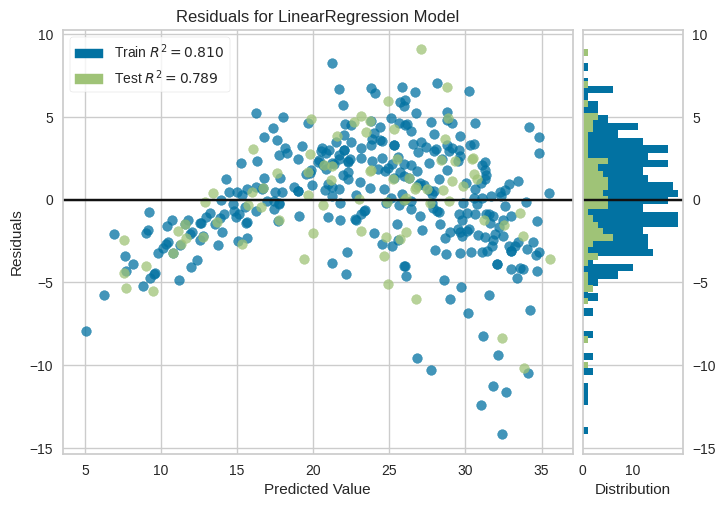

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [55]:
from yellowbrick.regressor import ResidualsPlot
visualizer = ResidualsPlot(lm_model)
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

### Summary and Conclusion

### Conclusion on Linear Regression Model

Our Linear Regression model achieved an **R-squared score of approximately 0.79**, indicating that about 79% of the variance in MPG can be explained by the features included in the model (cylinders, horsepower, weight, and age). This suggests that the model provides a reasonably good fit to the data.

The `PredictionError` plot shows that the predicted values generally align well with the actual values, although there's some scatter, particularly at higher MPG values. The `ResidualsPlot` shows a fairly random distribution of residuals around zero, which is desirable and suggests that the linear model assumptions are largely met, with no clear patterns indicating systematic under or over-prediction across the range of predicted values.